In [1]:
import pandas as pd
print("pandas aman")

pandas aman


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nyc_taxi.utils.db_utils import query_to_df

2026-05-17 21:36:42.941 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-05-17 21:36:42.956 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


In [6]:
query = """
SELECT *
FROM silver.yellow_trips
USING SAMPLE 100000 ROWS
"""

df = query_to_df(query)

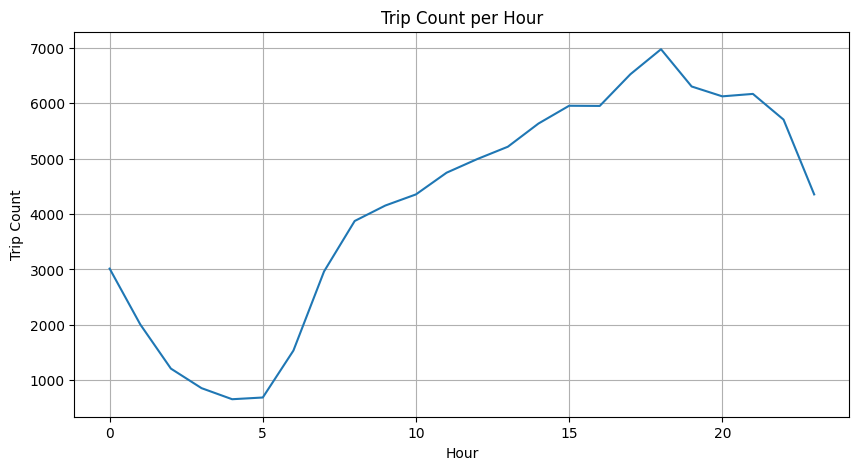

In [7]:
trip_per_hour = (
    df.groupby("pickup_hour")
      .size()
      .reset_index(name="trip_count")
)

plt.figure(figsize=(10,5))
plt.plot(
    trip_per_hour["pickup_hour"],
    trip_per_hour["trip_count"]
)

plt.xlabel("Hour")
plt.ylabel("Trip Count")
plt.title("Trip Count per Hour")
plt.grid(True)

plt.show()

In [8]:
trip_per_hour = (
    df.groupby("pickup_hour")
      .size()
      .reset_index(name="trip_count")
      .sort_values("pickup_hour")
)

trip_per_hour

,pickup_hour,trip_count
0,0,3016
1,1,2008
2,2,1210
3,3,857
4,4,657
5,5,688
6,6,1536
7,7,2965
8,8,3876
9,9,4155


In [9]:
revenue_per_hour = (
    df.groupby("pickup_hour")["total_amount"]
      .mean()
      .reset_index()
)

revenue_per_hour

,pickup_hour,total_amount
0,0,26.884188
1,1,25.855229
2,2,23.921702
3,3,25.205204
4,4,29.682831
5,5,34.751948
6,6,29.384954
7,7,26.723646
8,8,25.613767
9,9,25.550058


In [10]:
# pengaruh cuaca 

rain_analysis = (
    df.groupby("is_raining")
      .size()
      .reset_index(name="trip_count")
)

rain_analysis

,is_raining,trip_count
0,False,56318
1,True,43682


In [11]:
# revenue per hour berdasarkan cuaca

revenue_rain = (
    df.groupby("is_raining")["total_amount"]
      .mean()
      .reset_index(name="avg_revenue")
)

revenue_rain

,is_raining,avg_revenue
0,False,27.340680
1,True,27.273613


In [12]:
print(df.columns.tolist())

['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'pickup_location_id', 'dropoff_location_id', 'fare_amount', 'tip_amount', 'total_amount', 'trip_duration_min', 'location_id', 'pickup_borough', 'pickup_zone', 'pickup_hour', 'day_name', 'tip_percentage', 'temperature_2m_max', 'precipitation_sum', 'weathercode', 'is_raining']


mapping kategori cuaca 

In [13]:
df["weather_label"] = df["weathercode"].map({
    0: "Clear",
    1: "Mainly Clear",
    2: "Partly Cloudy",
    3: "Overcast",
    45: "Fog",
    48: "Fog",
    51: "Light Drizzle",
    53: "Drizzle",
    55: "Heavy Drizzle",
    61: "Light Rain",
    63: "Rain",
    65: "Heavy Rain",
    71: "Light Snow",
    73: "Snow",
    75: "Heavy Snow"
})

In [14]:
weather_category_analysis = (
    df.groupby("weather_label")["total_amount"]
      .mean()
      .reset_index(name="avg_revenue")
      .sort_values("avg_revenue", ascending=False)
)

weather_category_analysis

,weather_label,avg_revenue
9,Partly Cloudy,30.120782
2,Heavy Rain,28.853835
1,Heavy Drizzle,28.845530
4,Light Drizzle,27.830492
5,Light Rain,27.823162
10,Rain,27.796286
7,Mainly Clear,27.718386
8,Overcast,27.238535
6,Light Snow,26.973755
11,Snow,26.222887


In [15]:
weather_trip_analysis = (
    df.groupby("weather_label")
      .size()
      .reset_index(name="trip_count")
      .sort_values("trip_count", ascending=False)
)

weather_trip_analysis

,weather_label,trip_count
8,Overcast,52200
10,Rain,9237
4,Light Drizzle,7751
11,Snow,5971
6,Light Snow,4833
5,Light Rain,4570
0,Drizzle,3855
3,Heavy Snow,3393
7,Mainly Clear,2546
2,Heavy Rain,2394


In [16]:
revenue_per_hour = (
    df.groupby("pickup_hour")["total_amount"]
      .mean()
      .reset_index(name="avg_revenue")
)

revenue_per_hour

,pickup_hour,avg_revenue
0,0,26.884188
1,1,25.855229
2,2,23.921702
3,3,25.205204
4,4,29.682831
5,5,34.751948
6,6,29.384954
7,7,26.723646
8,8,25.613767
9,9,25.550058


In [17]:
tip_per_hour = (
    df.groupby("pickup_hour")["tip_percentage"]
      .mean()
      .reset_index(name="avg_tip_percentage")
)

tip_per_hour

,pickup_hour,avg_tip_percentage
0,0,15.665511
1,1,16.292610
2,2,15.150107
3,3,14.290828
4,4,11.227960
5,5,11.565407
6,6,13.655814
7,7,15.885164
8,8,16.883847
9,9,18.912919
